In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed_data.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,0,0,0,1,1,0,0,0,1,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,0,1,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,0,1,1,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,0,1,0,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,1,0,0,0,1,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   Default                       255347 non-null  int64  
 10  Loan_to_Income                255347 non-null  float64
 11  Income_per_CreditLine         255347 non-null  float64
 12  Employment_Stability          255347 non-null  float64


# Splitting features into X and y

In [4]:
X = df.drop('Default', axis=1)
y = df['Default']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model Training

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accuracy, precision, recall, f1])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

    results_df = results_df.sort_values(by="Recall", ascending=False)
    print("\n\nModel Comparison:")
    print(results_df)


Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.58      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.73      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070


Confusion Matrix:
[[45027   143]
 [ 5701   199]]


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.885569   0.852294  0.885569  0.837939

Model: KNN

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     45170
           1       0.28      0.06      0.10      5900

    accuracy                           0.87     51070
   macro avg       0.58      0.52      0.52     51070
weighted avg       0.82      0.87      0.84     51070


Confusion Matrix:
[[44240   930]
 [ 5537   363]]


Model Co

`Recall is the most critical metric because failing to identify a defaulter (False Negative) can lead to direct financial losses for the bank. However, F1-score can also be used to balance recall with precision and evaluate performance on imbalanced datasets.`

# Hyperparameter Tuning

**Logistic Regression**

In [9]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'class_weight': [None, 'balanced'],
}

In [10]:
lr_model = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [11]:
lr_model.fit(X_train_scaled,y_train)

print(lr_model.best_params_)
print(lr_model.best_score_)

{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2'}
0.6854712293256822


**Decision Tree**

In [12]:
dt_params = {
    'max_depth':[5,10,15,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'class_weight': [None, 'balanced']
}

In [13]:
dt_model = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)


In [14]:
dt_model.fit(X_train,y_train)

print(dt_model.best_params_)
print(dt_model.best_score_)

{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.6568824734958845


**Random Forest**

In [15]:
rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'class_weight': [None, 'balanced']
}


In [16]:
rf_model = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [17]:
rf_model.fit(X_train, y_train)

print(rf_model.best_params_)
print(rf_model.best_score_)

{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
0.6312887480751975


**Gradient Boosting**

In [18]:
gb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}


In [19]:
gb_model = GridSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
) 

In [20]:
gb_model.fit(X_train,y_train)

print(gb_model.best_params_)
print(gb_model.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
0.0752746391341435


**KNN**

In [21]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [22]:
knn_model = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)


In [23]:
knn_model.fit(X_train_scaled, y_train)

print("Best Params:", knn_model.best_params_)
print("Best Score:", knn_model.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best Score: 0.10125067963531223


**Adaboost**

In [24]:
ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

In [25]:
ada_model = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [26]:
ada_model.fit(X_train, y_train)

print("Best Params:", ada_model.best_params_)
print("Best Score:", ada_model.best_score_)

Best Params: {'learning_rate': 1.0, 'n_estimators': 200}
Best Score: 0.06239203270225659


# Evaluation Table after hyperparameter optimization

In [27]:
table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
    ],
    "Recall": [
        lr_model.best_score_,
        knn_model.best_score_,
        dt_model.best_score_,
        rf_model.best_score_,
        ada_model.best_score_,
        gb_model.best_score_,
    ]
})

table.sort_values(by="Recall", ascending=False)

,Model,Recall
0,Logistic Regression,0.685471
2,Decision Tree,0.656882
3,Random Forest,0.631289
1,KNN,0.101251
5,Gradient Boosting,0.075275
4,AdaBoost,0.062392


In [28]:
best_model = lr_model.best_estimator_
best_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [29]:
print("Best Model: Logistic Regression")
print("Recall:", lr_model.best_score_)

Best Model: Logistic Regression
Recall: 0.6854712293256822


Because the dataset was imbalanced and the business cost of missing a defaulter is high, Recall was selected as the primary metric. Logistic Regression was chosen because it identified 68% of defaulters.

In [30]:
import joblib
joblib.dump(best_model, "../model/loan_default_risk_model.pkl")
joblib.dump(X.columns.tolist(), "../model/feature_columns.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

# Feature Importance 

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
})

In [32]:
feature_importance['Importance'] = abs(
    feature_importance['Coefficient']
)


In [33]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                         Feature  Coefficient  Importance
0                            Age    -0.599255    0.599255
9                 Loan_to_Income     0.473596    0.473596
6                   InterestRate     0.462743    0.462743
4                 MonthsEmployed    -0.324629    0.324629
18     EmploymentType_Unemployed     0.195248    0.195248
27               HasCoSigner_Yes    -0.141428    0.141428
16      EmploymentType_Part-time     0.124456    0.124456
22             HasDependents_Yes    -0.122981    0.122981
3                    CreditScore    -0.122070    0.122070
17  EmploymentType_Self-employed     0.110853    0.110853
5                 NumCreditLines     0.109409    0.109409
19         MaritalStatus_Married    -0.102960    0.102960
25              LoanPurpose_Home    -0.078292    0.078292
21               HasMortgage_Yes    -0.077515    0.077515
15                 Education_PhD    -0.071084    0.071084
8                       DTIRatio     0.063295    0.063295
14            

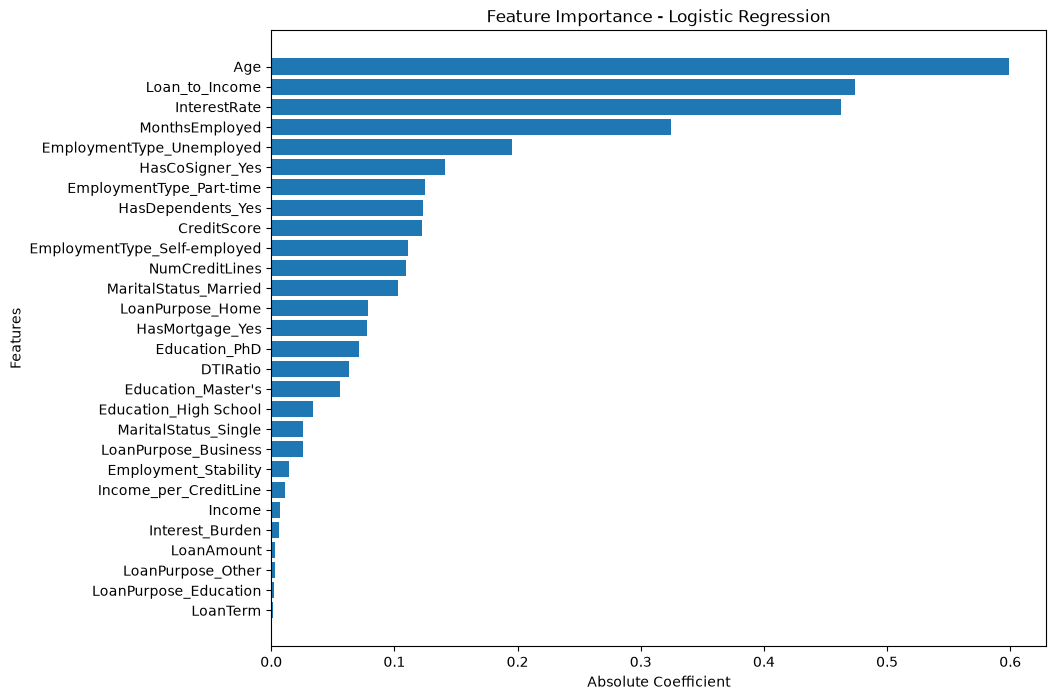

In [34]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')
plt.title('Feature Importance - Logistic Regression')
plt.show()